In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from experiments import ComparisonConfig, load_datasets, run_comparison
from experiments.plots import (
    summary_table, learning_curves, rollout_curves, physics_curves,
    equation_curves, forcing_curves, field_slices,
)

torch.set_num_threads(1)
if not torch.cuda.is_available():
    raise RuntimeError("Select the research kernel with CUDA access")
plt.rcParams.update({"font.size": 11, "figure.dpi": 120, "savefig.dpi": 180})
from nsdata import generate_dataset, save_dataset

In [2]:
data_directory = root / "datasets" / "large"
families = ("wave", "taylor_green", "random")
for family in families:
    path = data_directory / f"{family}.pt"
    if not path.is_file():
        data = generate_dataset(
            family, grid_size=24, n_trajectories=32, n_snapshots=41,
            seed=142, device="cuda",
        )
        save_dataset(data, path, overwrite=True)
        del data

In [3]:
datasets = load_datasets(data_directory, families)
config = ComparisonConfig(
    device="cuda",
    cutoff=(7, 7, 7),
    train_indices=tuple(range(24)),
    validation_indices=tuple(range(24, 28)),
    test_indices=tuple(range(28, 32)),
    seeds=(7, 17, 27),
    steps=3000,
    batch_size=24,
    eval_every=100,
)
output = root / "results" / "phfno_fno_large"

In [4]:
results = run_comparison(datasets, config, output)

PHFNO seed 7:   0%|          | 0/3000 [00:00<?, ?step/s]

FNOBaseline seed 7:   0%|          | 0/3000 [00:00<?, ?step/s]

FNOBaseline seed 17:   0%|          | 0/3000 [00:00<?, ?step/s]

PHFNO seed 17:   0%|          | 0/3000 [00:00<?, ?step/s]

PHFNO seed 27:   0%|          | 0/3000 [00:00<?, ?step/s]

FNOBaseline seed 27:   0%|          | 0/3000 [00:00<?, ?step/s]

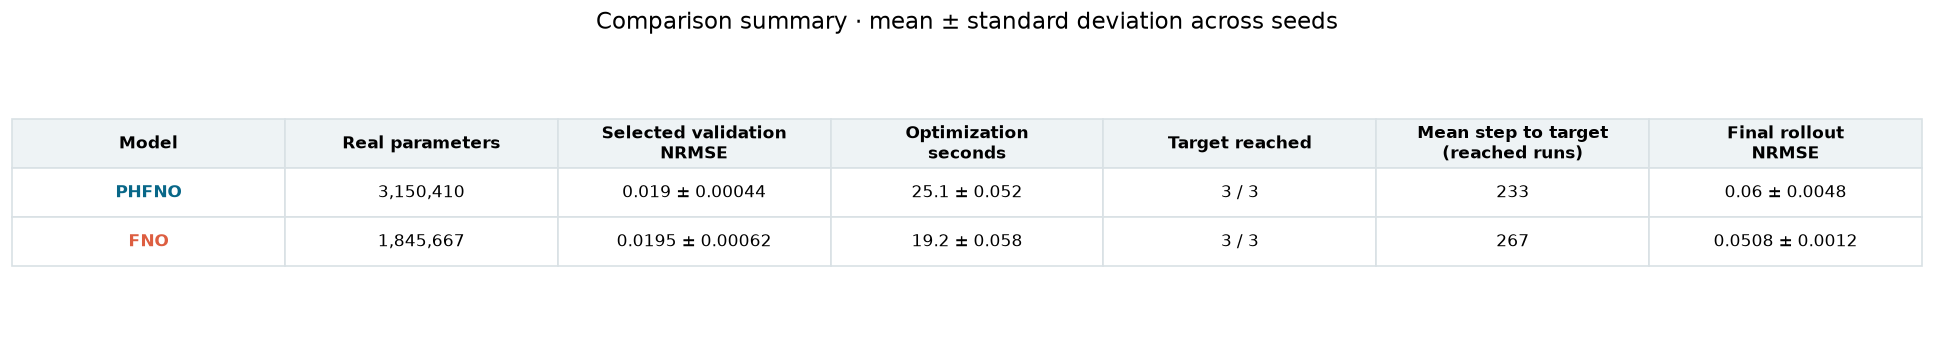

In [5]:
figure = summary_table(results)
plt.show()

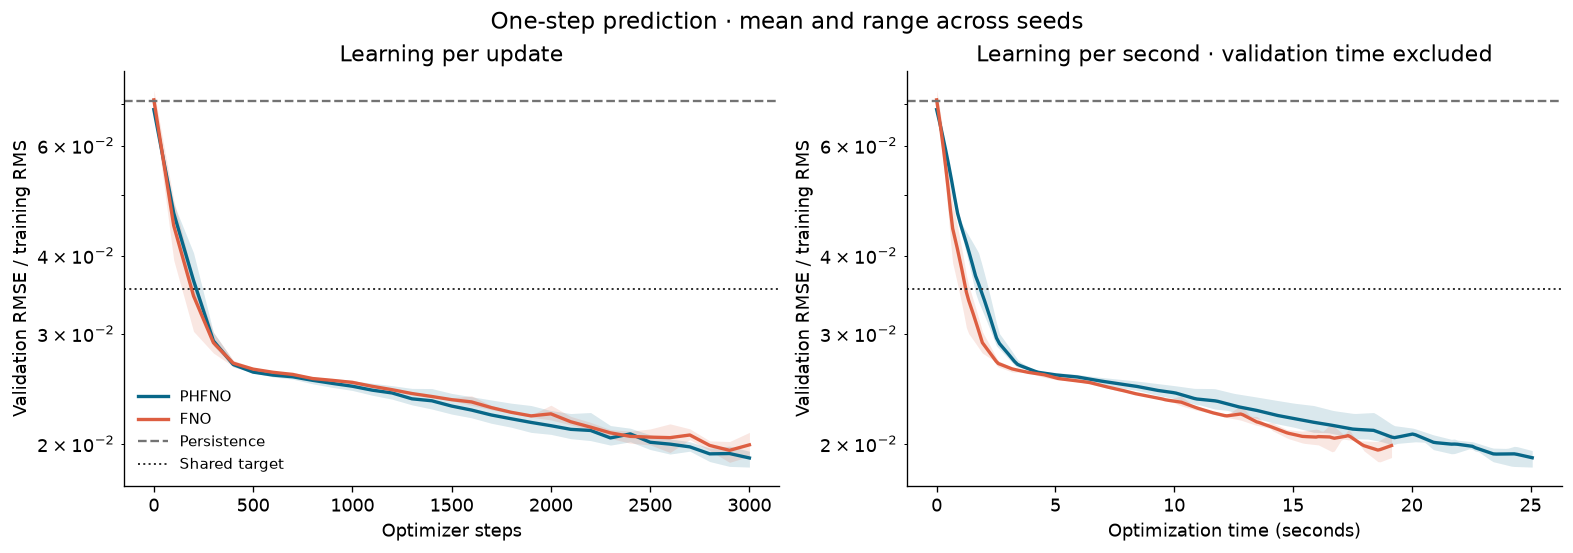

In [6]:
figure = learning_curves(results)
plt.show()

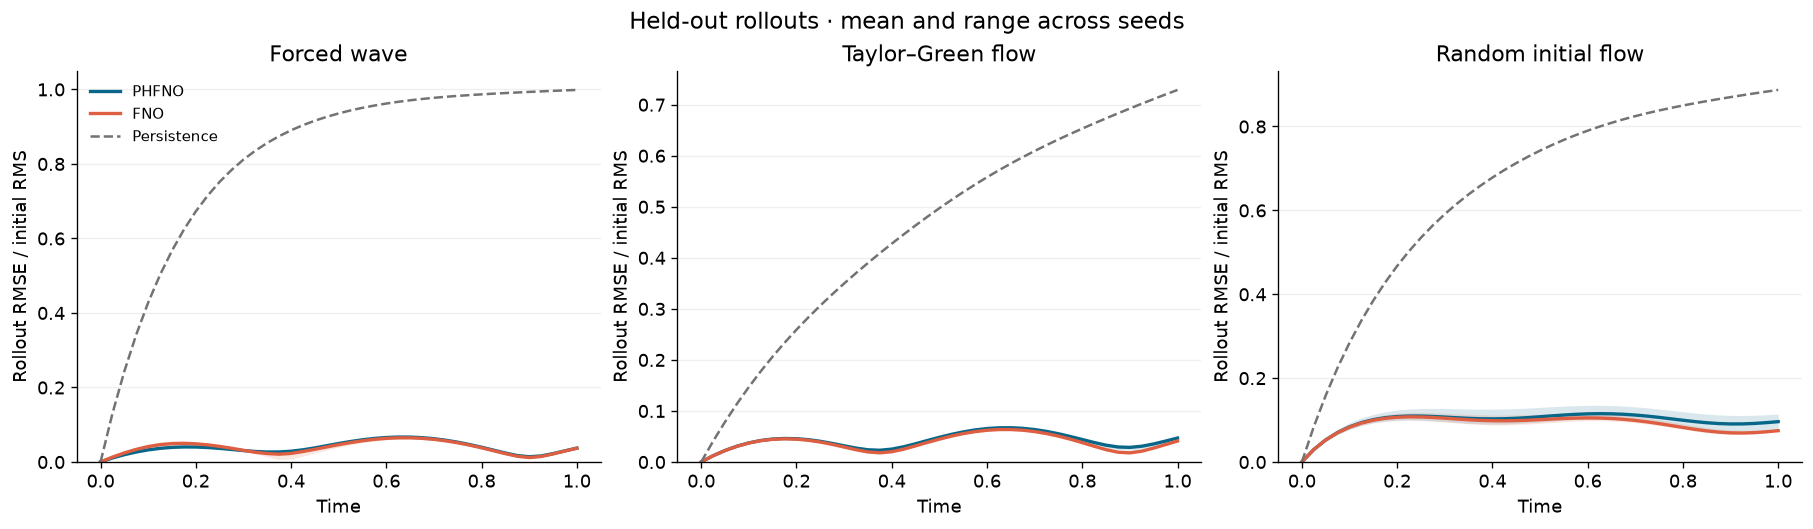

In [7]:
figure = rollout_curves(results)
plt.show()

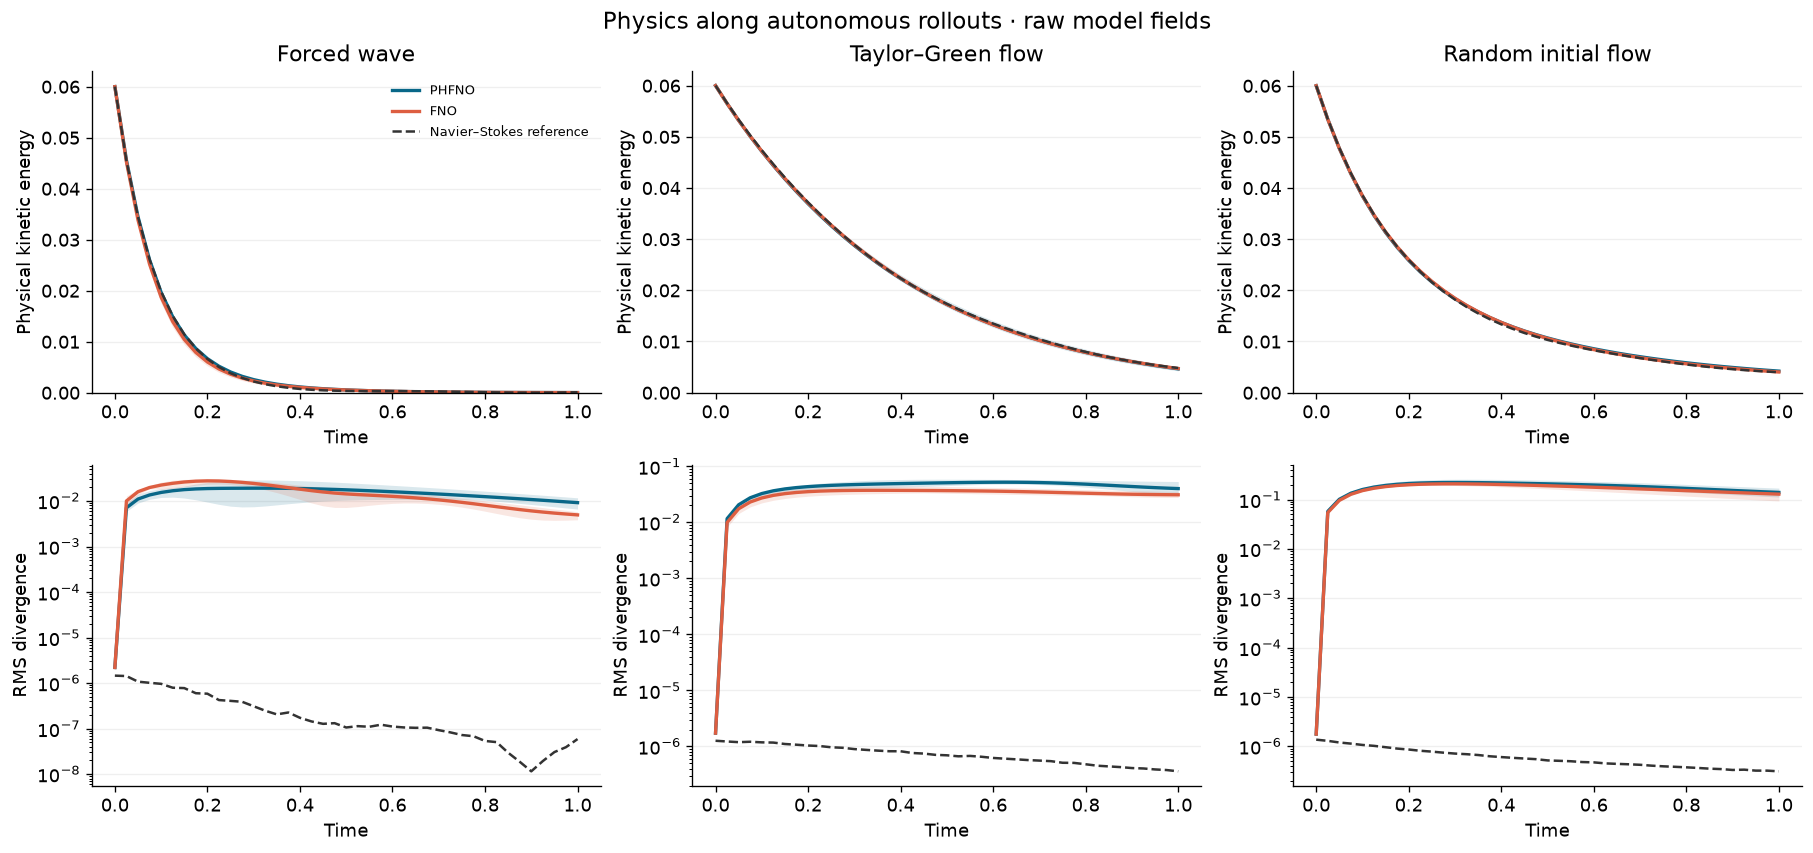

In [8]:
figure = physics_curves(results)
plt.show()

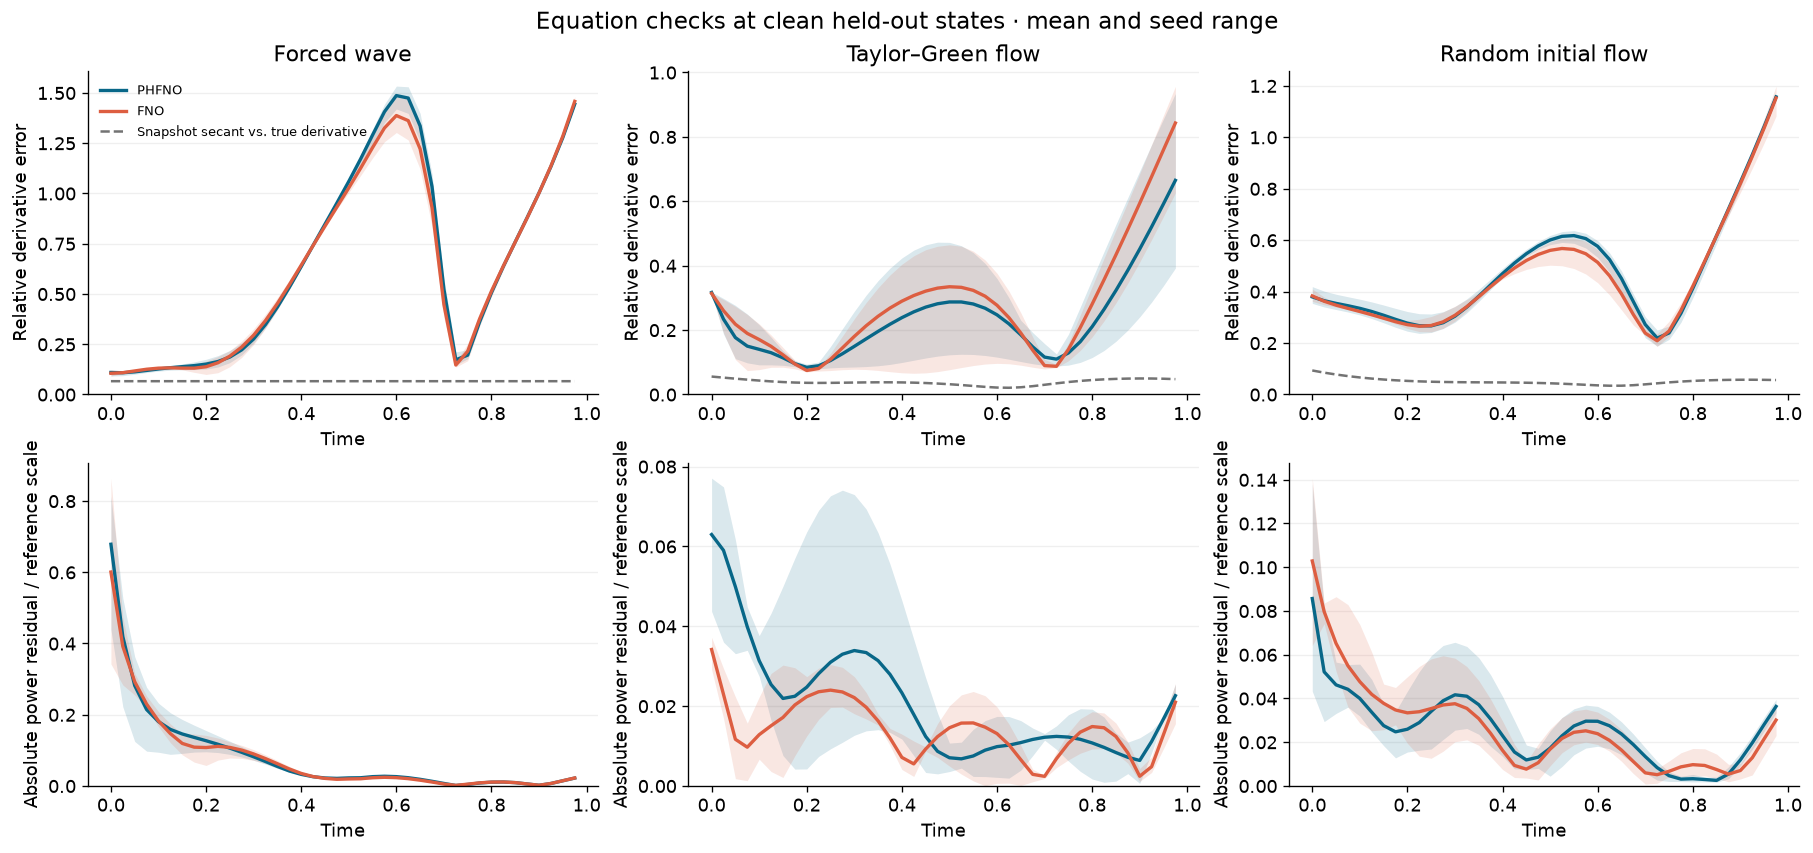

In [9]:
figure = equation_curves(results)
plt.show()

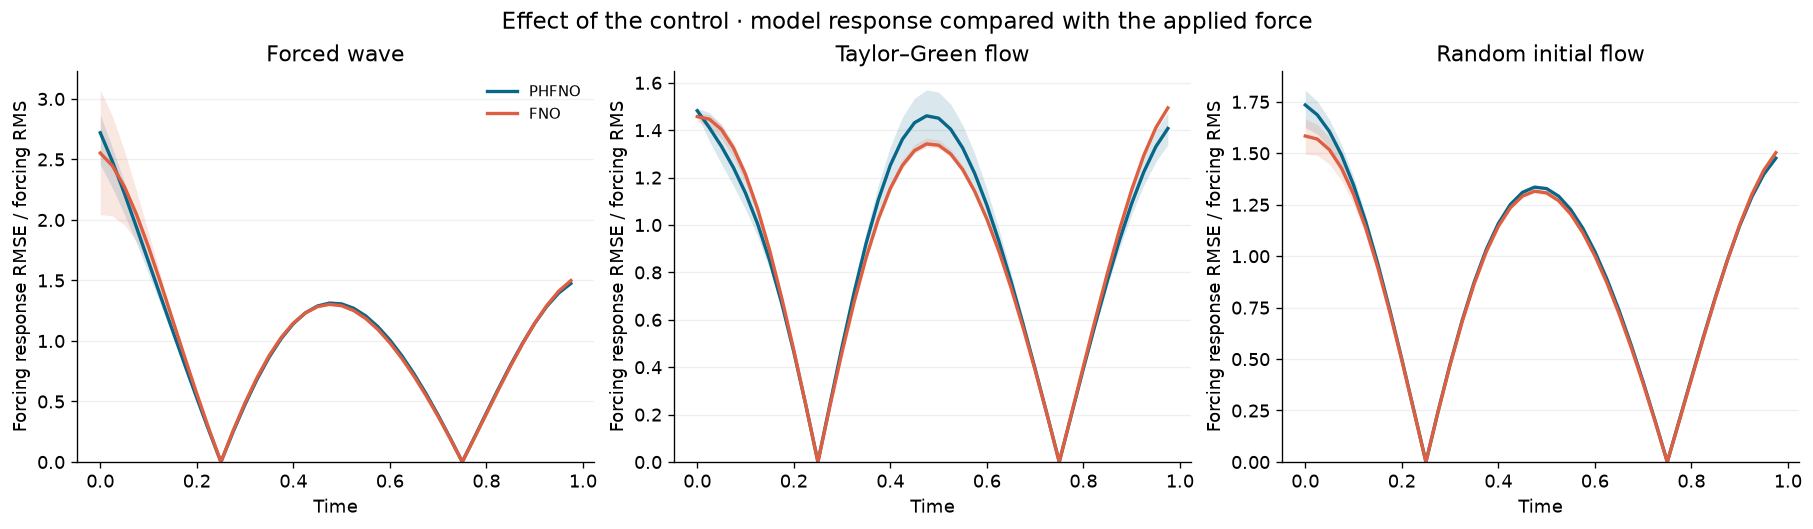

In [10]:
figure = forcing_curves(results)
plt.show()

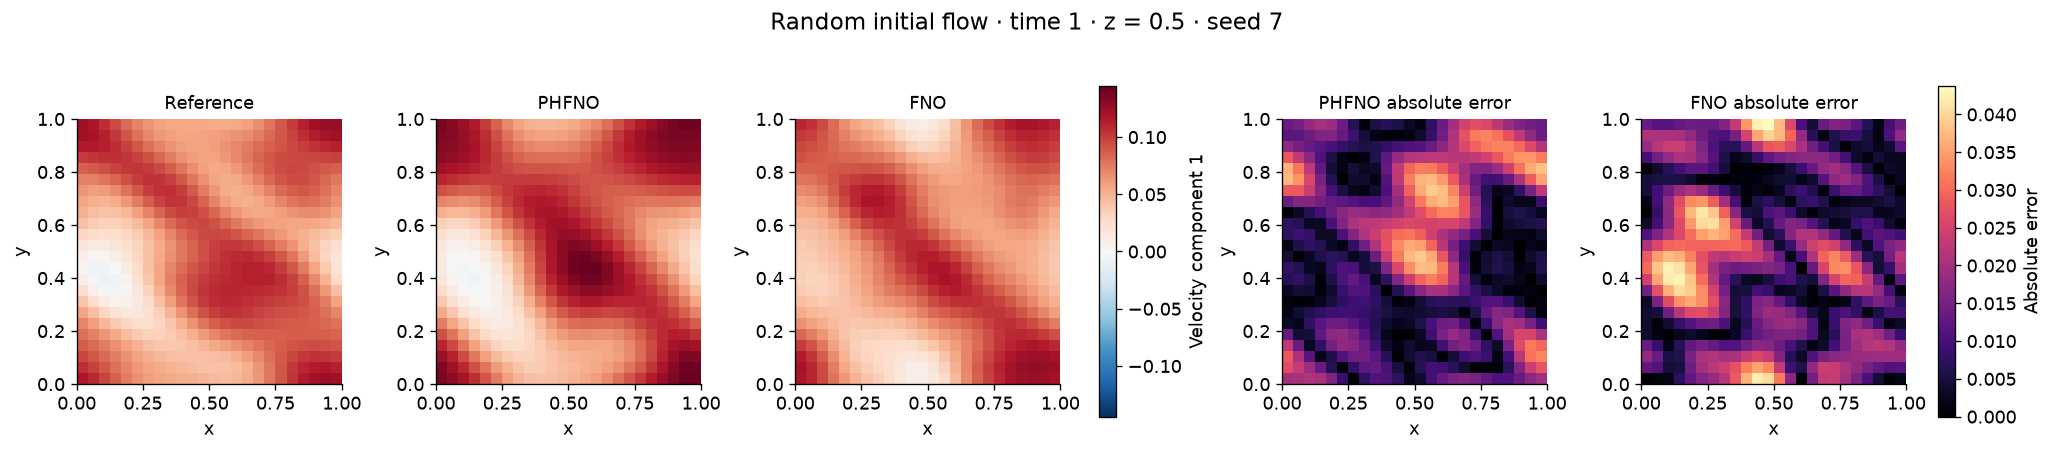

In [11]:
figure = field_slices(results, family="random", seed=config.seeds[0])
plt.show()